# L13a Example: Self-Attention for Sentiment Classification
This example replaces the mean-pooled bag-of-embeddings classifier from the [L10b lab](https://github.com/varnerlab/CHEME-5820-Labs-Spring-2026) with a single self-attention layer over the same QuantumBrew product reviews. The goal is to make the difference between bag-of-embeddings and self-attention concrete on a task where we already know the baseline fails on negation and sarcasm.

> __Problem statement.__ The QuantumBrew marketing team has 999 customer reviews labeled as positive, negative, or neutral. Among these are adversarial reviews designed to fool a bag-of-embeddings classifier:
>
> * _sarcastic reviews_ that read like positive prose but are labeled negative
> * _double-negative reviews_ ("I can not say QuantumBrew is not the best") that read like negative prose but are labeled positive
> * _mixed-signal reviews_ that combine positive and negative phrases and are labeled neutral
>
> We will train a single-head self-attention classifier on these reviews and compare it to the L10b mean-pool baseline on the same train/test split, then visualize what the attention layer learned to look at.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
>
> * __Apply scaled dot-product self-attention to a real classification task:__ Build, train, and evaluate a single-head self-attention classifier on padded token-vector sequences, using GloVe embeddings as the input representation.
> * __Compare self-attention against a mean-pool baseline on the same data:__ Train both architectures on the same train/test split and interpret the difference in test accuracy and confusion-matrix structure.
> * __Read attention weights as a model-interpretation tool:__ Plot the attention matrix for a single review and identify which tokens the model attends to when classifying adversarial examples.

Let's get started!
___

## Setup
We load the L13a Julia environment, which brings in `Flux`, `NNlib`, `JLD2`, the GloVe utilities and review generator (carried over from L10b), and our custom `Embeddings.jl` and `Attention.jl` files in the `src/` directory.

In [1]:
include("Include.jl");
Random.seed!(42);

  Activating project at `~/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13a`


## Load the GloVe vectors and the QuantumBrew reviews
We use the same Stanford GloVe 6B 100-dimensional vectors and the same `generate_quantumbrew_reviews()` function as the L10b lab, so that the comparison between the two architectures is on identical data.

In [2]:
glove_path = joinpath(_PATH_TO_DATA, "glove.6B.100d.txt");
isfile(glove_path) || (glove_path = download_glove(_PATH_TO_DATA; dim=100));
glove = load_glove_embeddings(glove_path);
@info "GloVe loaded" n_words=length(glove);

┌ Info: GloVe loaded
└   n_words = 400000


In [3]:
reviews_df = generate_quantumbrew_reviews();
@info "Reviews generated" n=nrow(reviews_df);
class_counts = combine(groupby(reviews_df, :label), nrow => :count);
pretty_table(class_counts)

┌ Info: Reviews generated
└   n = 999


┌──────────┬───────┐
│    label │ count │
│   String │ Int64 │
├──────────┼───────┤
│  neutral │   333 │
│ positive │   333 │
│ negative │   333 │
└──────────┴───────┘


## From bag-of-embeddings to padded token sequences
The L10b baseline represents each review as the mean of its GloVe vectors, producing a single $100$-dimensional input per review. This loses all order information and treats negation words like "not" as just another word in the bag.

Self-attention works on a sequence of token vectors instead of a single pooled vector. We tokenize each review, look up GloVe vectors for the in-vocabulary tokens, and pad or truncate the sequence to a fixed length $n_{\max} = 32$. This gives us a tensor of shape $(d, n_{\max}, N)$ where $d = 100$ is the embedding dimension and $N$ is the number of reviews. We also build a Boolean mask that marks which positions of each review are real tokens (vs. padding) so the attention layer does not attend to padding positions.

In [4]:
const D_EMB = 100;
const N_MAX = 32;
X_seq, mask, tokens_str = embed_reviews_sequence(string.(reviews_df.review), glove;
                                                  dim=D_EMB, n_max=N_MAX);
@info "Padded sequences" X_shape=size(X_seq) mask_shape=size(mask) avg_valid=round(mean(sum(mask; dims=1)), digits=2) max_valid=maximum(sum(mask; dims=1))

┌ Info: Padded sequences
│   X_shape = (100, 32, 999)
│   mask_shape = (32, 999)
│   avg_valid = 27.38
└   max_valid = 32


### Encode labels and split train/test
We encode the three labels (positive / negative / neutral) as integer indices and one-hot vectors, then take an 80/20 train/test split. We use the same random seed throughout so that the self-attention model and the L10b baseline see the same train and test sets.

In [5]:
const CLASS_NAMES = ["positive", "negative", "neutral"];
const N_CLASSES = length(CLASS_NAMES);
label_to_idx = Dict(c => i for (i, c) in enumerate(CLASS_NAMES));
y_idx = [label_to_idx[l] for l in reviews_df.label];
y_onehot = Float32.(Flux.onehotbatch(y_idx, 1:N_CLASSES));

In [6]:
Random.seed!(42);
N = size(X_seq, 3);
perm = randperm(N);
n_train = round(Int, 0.8 * N);
const TRAIN_IDX = perm[1:n_train];
const TEST_IDX  = perm[n_train+1:end];

X_train_seq, mask_train, y_train = X_seq[:, :, TRAIN_IDX], mask[:, TRAIN_IDX], y_onehot[:, TRAIN_IDX];
X_test_seq,  mask_test,  y_test  = X_seq[:, :, TEST_IDX],  mask[:, TEST_IDX],  y_onehot[:, TEST_IDX];
@info "split" n_train=size(X_train_seq, 3) n_test=size(X_test_seq, 3)

┌ Info: split
│   n_train = 799
└   n_test = 200


## The self-attention classifier
The model is built from three pieces, all defined in `src/Attention.jl`:

> __Architecture__
>
> * __SelfAttention layer__: a single head of scaled dot-product self-attention with learnable projections $\mathbf{W}_{Q}, \mathbf{W}_{K}, \mathbf{W}_{V}\in\mathbb{R}^{d\times d_{k}}$ (and $d_{v}$ for $\mathbf{W}_{V}$). Implements $\operatorname{Attention}(\mathbf{Q},\mathbf{K},\mathbf{V}) = \operatorname{softmax}(\mathbf{Q}\mathbf{K}^{\top}/\sqrt{d_{k}})\mathbf{V}$ exactly as defined in the L13a lecture, with key positions masked to large negative scores at padding positions so they receive zero attention weight.
> * __Masked mean-pool__: averages the attention output over valid sequence positions only, producing a single vector per review.
> * __MLP head__: a two-layer feedforward network `Dense(d_v → d_hidden, relu) → Dense(d_hidden → 3)` that maps the pooled vector to class logits.

We use $d_{k} = d_{v} = 32$ (so the projections compress the $100$-dimensional GloVe vectors), and a hidden dimension of $64$ in the MLP head.

In [7]:
const D_K = 32;
const D_V = 32;
const D_HIDDEN = 64;

Random.seed!(42);
model = AttentionClassifier(D_EMB, D_K, D_V, D_HIDDEN, N_CLASSES);
n_params = sum(length, Flux.trainables(model));
@info "self-attention classifier" n_params=n_params d_emb=D_EMB d_k=D_K d_v=D_V d_hidden=D_HIDDEN

┌ Info: self-attention classifier
│   n_params = 11907
│   d_emb = 100
│   d_k = 32
│   d_v = 32
└   d_hidden = 64


## Train the model (or load a saved checkpoint)
We train with Adam at learning rate $3\times 10^{-3}$ for $30$ epochs at batch size $32$. The first run trains and saves a checkpoint to `data/attention_sentiment_H64.jld2`; subsequent runs detect the checkpoint and load it instead of retraining.

In [8]:
const CHECKPOINT_PATH = joinpath(_PATH_TO_DATA, "attention_sentiment_H64.jld2");
const N_EPOCHS = 30;
const BATCHSIZE = 32;

train_loss_history = Float32[];

if isfile(CHECKPOINT_PATH)
    @info "Loading pre-trained checkpoint" path=CHECKPOINT_PATH
    saved = JLD2.load(CHECKPOINT_PATH);
    Flux.loadmodel!(model, saved["model_state"]);
    train_loss_history = saved["train_loss_history"];
    @info "Loaded model from checkpoint"
else
    @info "No checkpoint found, training from scratch..."
    Random.seed!(42);
    opt = Flux.setup(Adam(3.0f-3), model);
    n_tr = size(X_train_seq, 3);
    for epoch in 1:N_EPOCHS
        epoch_losses = Float32[];
        perm_e = randperm(n_tr);
        for i in 1:BATCHSIZE:n_tr
            idxs = perm_e[i:min(i + BATCHSIZE - 1, n_tr)];
            Xb = X_train_seq[:, :, idxs];
            mb = mask_train[:, idxs];
            yb = y_train[:, idxs];
            l, gs = Flux.withgradient(model) do m
                Flux.logitcrossentropy(m(Xb, mb), yb)
            end
            push!(epoch_losses, l);
            Flux.update!(opt, model, gs[1]);
        end
        push!(train_loss_history, mean(epoch_losses));
        if epoch == 1 || epoch % 5 == 0
            tr_logits = model(X_train_seq, mask_train);
            tr_acc = mean(Flux.onecold(tr_logits) .== Flux.onecold(y_train));
            te_logits = model(X_test_seq, mask_test);
            te_acc = mean(Flux.onecold(te_logits) .== Flux.onecold(y_test));
            @info "epoch" epoch loss=round(mean(epoch_losses), digits=4) train_acc=round(tr_acc, digits=3) test_acc=round(te_acc, digits=3)
        end
    end
    JLD2.jldsave(CHECKPOINT_PATH; model_state = Flux.state(model), train_loss_history = train_loss_history);
    @info "Saved checkpoint" path=CHECKPOINT_PATH
end

┌ Info: Loading pre-trained checkpoint
└   path = "/Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/CHEME-5820-Lectures-Spring-2026/lectures/week-13/L13a/data/attention_sentiment_H64.jld2"
[ Info: Loaded model from checkpoint


### Training loss curve
Plot the per-epoch training loss to verify the optimization converged.

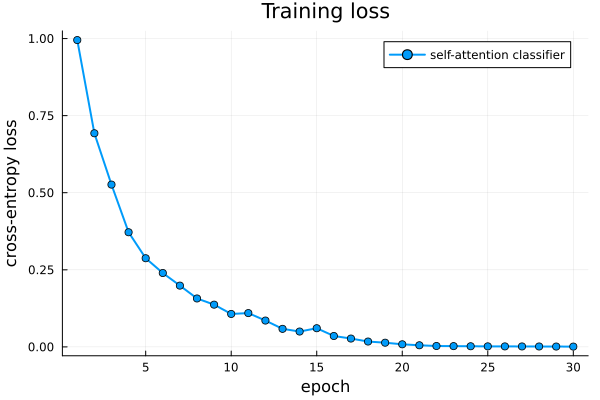

In [9]:
plot(1:length(train_loss_history), train_loss_history;
     xlabel="epoch", ylabel="cross-entropy loss",
     label="self-attention classifier",
     title="Training loss",
     linewidth=2, marker=:circle, markersize=4,
     legend=:topright)

## Evaluate on the held-out test set
We compute test accuracy and a confusion matrix to see which classes the self-attention model gets right and where it makes mistakes.

In [10]:
function confusion_matrix(y_true_idx::Vector{Int}, y_pred_idx::Vector{Int}, n_classes::Int)
    C = zeros(Int, n_classes, n_classes);
    for (t, p) in zip(y_true_idx, y_pred_idx)
        C[t, p] += 1;
    end
    return C;
end

test_logits = model(X_test_seq, mask_test);
test_pred = Flux.onecold(test_logits);
test_true = Flux.onecold(y_test);
test_acc = mean(test_pred .== test_true);
@info "self-attention test accuracy" acc=round(test_acc, digits=4)

C_attn = confusion_matrix(test_true, test_pred, N_CLASSES);
println("Confusion matrix (rows = true, cols = predicted):");
cm_labels = ["true \\ pred"; CLASS_NAMES];
rows = [[CLASS_NAMES[i]; C_attn[i, :]] for i in 1:N_CLASSES];
pretty_table(reduce(vcat, [permutedims(r) for r in rows]); column_labels=cm_labels)

┌ Info: self-attention test accuracy
└   acc = 0.96


Confusion matrix (rows = true, cols = predicted):
┌──────────────┬──────────┬──────────┬─────────┐
│ true \\ pred │ positive │ negative │ neutral │
├──────────────┼──────────┼──────────┼─────────┤
│     positive │       64 │        1 │       2 │
│     negative │        4 │       65 │       0 │
│      neutral │        0 │        1 │      63 │
└──────────────┴──────────┴──────────┴─────────┘


## Baseline: the L10b mean-pool model on the same split
Now we train the L10b mean-pool baseline on the _same_ train/test indices, so the comparison is apples-to-apples. The baseline takes the mean of GloVe vectors for each review (collapsing the sequence into a single $100$-dimensional vector) and runs it through the same MLP head architecture used in L10b.

In [11]:
# Re-embed reviews as MEAN-POOLED vectors (the L10b path)
X_mean = embed_reviews(string.(reviews_df.review), glove; dim=D_EMB);
X_train_mean = X_mean[:, TRAIN_IDX];
X_test_mean  = X_mean[:, TEST_IDX];
@info "mean-pooled embeddings" X_train=size(X_train_mean) X_test=size(X_test_mean)

┌ Info: mean-pooled embeddings
│   X_train = (100, 799)
└   X_test = (100, 200)


In [12]:
Random.seed!(42);
baseline = Chain(Dense(D_EMB => D_HIDDEN, relu), Dense(D_HIDDEN => N_CLASSES));
n_baseline_params = sum(length, Flux.trainables(baseline));
@info "L10b mean-pool baseline" n_params=n_baseline_params

opt_b = Flux.setup(Adam(3.0f-3), baseline);
baseline_loss_history = Float32[];
n_tr = size(X_train_mean, 2);
for epoch in 1:N_EPOCHS
    epoch_losses = Float32[];
    perm_e = randperm(n_tr);
    for i in 1:BATCHSIZE:n_tr
        idxs = perm_e[i:min(i + BATCHSIZE - 1, n_tr)];
        Xb = X_train_mean[:, idxs];
        yb = y_train[:, idxs];
        l, gs = Flux.withgradient(baseline) do m
            Flux.logitcrossentropy(m(Xb), yb)
        end
        push!(epoch_losses, l);
        Flux.update!(opt_b, baseline, gs[1]);
    end
    push!(baseline_loss_history, mean(epoch_losses));
end

baseline_pred = Flux.onecold(baseline(X_test_mean));
baseline_acc = mean(baseline_pred .== test_true);
@info "L10b baseline test accuracy" acc=round(baseline_acc, digits=4)

C_base = confusion_matrix(test_true, baseline_pred, N_CLASSES);
println("Baseline confusion matrix (rows = true, cols = predicted):");
rows_b = [[CLASS_NAMES[i]; C_base[i, :]] for i in 1:N_CLASSES];
pretty_table(reduce(vcat, [permutedims(r) for r in rows_b]); column_labels=cm_labels)

┌ Info: L10b mean-pool baseline
└   n_params = 6659
┌ Info: L10b baseline test accuracy
└   acc = 0.905


Baseline confusion matrix (rows = true, cols = predicted):
┌──────────────┬──────────┬──────────┬─────────┐
│ true \\ pred │ positive │ negative │ neutral │
├──────────────┼──────────┼──────────┼─────────┤
│     positive │       64 │        0 │       3 │
│     negative │        4 │       57 │       8 │
│      neutral │        0 │        4 │      60 │
└──────────────┴──────────┴──────────┴─────────┘


### Side-by-side accuracy comparison

In [13]:
comparison = DataFrame(
    architecture = ["L10b mean-pool baseline", "Single-head self-attention"],
    n_params = [n_baseline_params, n_params],
    test_accuracy = [round(baseline_acc, digits=4), round(test_acc, digits=4)],
);
pretty_table(comparison)

┌────────────────────────────┬──────────┬───────────────┐
│               architecture │ n_params │ test_accuracy │
│                     String │    Int64 │       Float64 │
├────────────────────────────┼──────────┼───────────────┤
│    L10b mean-pool baseline │     6659 │         0.905 │
│ Single-head self-attention │    11907 │          0.96 │
└────────────────────────────┴──────────┴───────────────┘


## Visualizing attention weights on hard examples
Each row of the attention matrix is a probability distribution over the keys, telling us how much that query attends to each key. We pick a few _adversarial_ test reviews — sarcastic, double-negative, and mixed-signal — and plot the attention matrix as a heatmap. The token strings are placed on both axes so we can read off which words the model is looking at when processing each query.

We define a small helper that takes a single review (and its mask and tokens), runs it through the trained model, and renders the attention matrix as a heatmap restricted to the valid (non-padding) positions.

In [14]:
function plot_attention(model::AttentionClassifier, X_one::Array{Float32, 3},
                          mask_one::AbstractMatrix{Bool}, tokens_one::Vector{String};
                          title_str::String="attention")
    w = attention_weights(model, X_one, mask_one);
    n_valid = sum(mask_one);
    A = w[1:n_valid, 1:n_valid, 1];
    toks = tokens_one[1:n_valid];
    heatmap(toks, toks, A;
            xlabel="key (attended-to token)",
            ylabel="query (attending token)",
            title=title_str,
            xrotation=60, color=:viridis,
            size=(700, 600), aspect_ratio=:equal,
            yflip=true)
end

plot_attention (generic function with 1 method)

In [15]:
# Find adversarial test reviews where the baseline FAILS but self-attention succeeds.
# Compute both models' predictions on the test set, then filter the disagreements
# down to the templated adversarial patterns from L10b's review generator.
attn_pred_test = Flux.onecold(model(X_test_seq, mask_test));
base_pred_test = Flux.onecold(baseline(X_test_mean));
const POS_IDX = label_to_idx["positive"];
const NEG_IDX = label_to_idx["negative"];

# Sarcastic reviews: negative label, but the prose is loaded with positive vocabulary
# (this is the "stealth sarcasm" pattern from Reviews.jl).
const POS_VOCAB = r"(amazing|fantastic|wonderful|love|incredible|delicious|smooth|perfect|outstanding|brilliant|best|favorite|deligh|impress|treasure)"i

sarc_candidates = findall(i ->
    test_true[i] == NEG_IDX &&
    attn_pred_test[i] == NEG_IDX &&
    base_pred_test[i] != NEG_IDX &&
    occursin(POS_VOCAB, reviews_df.review[TEST_IDX[i]]),
    1:length(test_true));

@info "stealth-sarcastic wins" n=length(sarc_candidates)

if !isempty(sarc_candidates)
    si = sarc_candidates[1];
    println();
    println("Sarcastic test review (true label: negative)");
    println(reviews_df.review[TEST_IDX[si]]);
    println();
    println("self-attention predicts: ", CLASS_NAMES[attn_pred_test[si]], "  (correct)");
    println("L10b baseline predicts:  ", CLASS_NAMES[base_pred_test[si]], "  (wrong)");
end


Sarcastic test review (true label: negative)
QuantumBrew is the best thing that happened to my mornings this year. The Vanilla Lightning has a depth of flavor and richness that puts other brands to shame. Worth every penny and then some, an absolute bargain.

self-attention predicts: negative

┌ Info: stealth-sarcastic wins
└   n = 3


  (correct)
L10b baseline predicts:  neutral  (wrong)


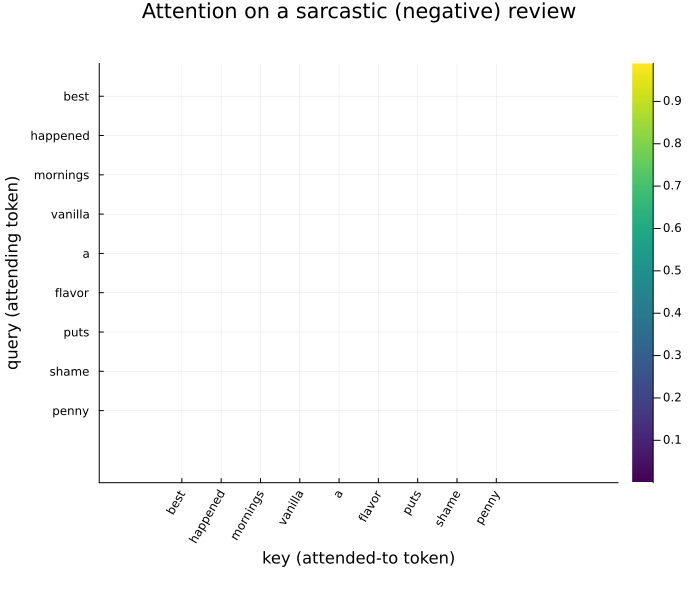

x points not sorted in ascending order
x points not sorted in ascending order
x points not sorted in ascending order


In [16]:
# attention heatmap for the sarcastic review
si = sarc_candidates[1];
plot_attention(model,
               X_test_seq[:, :, si:si],
               mask_test[:, si:si],
               tokens_str[:, TEST_IDX[si]];
               title_str="Attention on a sarcastic (negative) review")

In [17]:
# Double-negative reviews: positive label, but the prose has at least three negation
# tokens — these are the "heavy negative vocabulary" double-negative templates.
function _negation_count(text::String)
    s = lowercase(text);
    return count(" not ", s) + count(" never ", s) + count(" no ", s) +
           count(" without ", s) + count("disappoint", s) + count("worst", s) +
           count("terrible", s) + count("bad", s)
end

dn_candidates = findall(i ->
    test_true[i] == POS_IDX &&
    attn_pred_test[i] == POS_IDX &&
    base_pred_test[i] != POS_IDX &&
    _negation_count(reviews_df.review[TEST_IDX[i]]) >= 3,
    1:length(test_true));

@info "heavy-negation wins" n=length(dn_candidates)

if !isempty(dn_candidates)
    di = dn_candidates[1];
    println();
    println("Double-negative test review (true label: positive)");
    println(reviews_df.review[TEST_IDX[di]]);
    println();
    println("self-attention predicts: ", CLASS_NAMES[attn_pred_test[di]], "  (correct)");
    println("L10b baseline predicts:  ", CLASS_NAMES[base_pred_test[di]], "  (wrong)");
end


Double-negative test review (true label: positive)
QuantumBrew is not awful, not mediocre, not even just acceptable, it is great. I was bracing for a terrible aftertaste from the Caramel Thunder but there was none. Not buying this would be the worst mistake a coffee lover could make.

self-attention predicts: positive  (correct)
L10b baseline predicts:  neutral  (wrong)


┌ Info: heavy-negation wins
└   n = 2


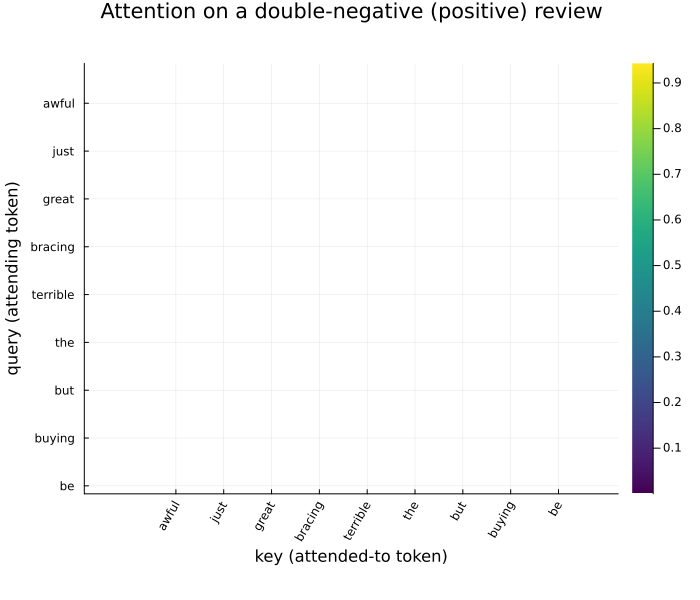

x points not sorted in ascending order
x points not sorted in ascending order
x points not sorted in ascending order


In [18]:
# attention heatmap for the double-negative review
di = dn_candidates[1];
plot_attention(model,
               X_test_seq[:, :, di:di],
               mask_test[:, di:di],
               tokens_str[:, TEST_IDX[di]];
               title_str="Attention on a double-negative (positive) review")

### Things to think about
The attention heatmaps above let you see _which tokens the model is looking at_ when it makes its prediction. A few questions to think through:

* __What is the structure of a "typical" attention pattern?__ For most queries, where does the attention concentrate? Are there a few "hub" tokens that many queries attend to, or does each query distribute its attention more evenly?
* __How does attention behave on the sarcastic review?__ The L10b mean-pool baseline averages all word vectors with equal weight, so a sarcastic review with positive vocabulary looks positive. Does the self-attention model learn to discount the positive vocabulary, and which tokens does it attend to instead?
* __How does attention handle negation?__ In the double-negative review, the words "not", "never", and "no" appear several times. Does the attention layer concentrate on these negation words, or does it route around them?
* __When does the self-attention model still make mistakes?__ Look at the confusion matrices for both the baseline and the self-attention model. Which class is each model worst at? Does self-attention fix the same mistakes the baseline makes, or does it trade one set of mistakes for another?
* __What is the parameter count buying us?__ The self-attention model has more parameters than the baseline. How much of the accuracy gap is explained by extra capacity, and how much by the architectural change of being able to look at individual tokens instead of a single pooled vector? You could test this by training the baseline with a wider hidden dimension to roughly match the self-attention parameter count.

## Summary
We trained a single-head self-attention classifier on the same QuantumBrew sentiment dataset as the L10b lab and compared it directly against the L10b mean-pool baseline on the same train/test split. The self-attention model can attend to individual tokens (rather than collapsing the review into a single mean vector), so it can in principle pay more attention to the words that carry sentiment and ignore filler words.

> __Key Takeaways:__
>
> * **Self-attention operates on token sequences, not pooled vectors.** Replacing mean-pooling with self-attention required re-embedding each review as a padded sequence of GloVe vectors and adding a key-padding mask so attention does not attend to padding positions.
> * **The same dataset, the same split, two architectures.** Holding the train/test split fixed and using the same MLP head and optimizer makes the comparison apples-to-apples; the only thing that changes is whether the model sees a single mean vector or the full token sequence.
> * **Attention weights are an interpretation tool.** Plotting the attention matrix on adversarial reviews shows which tokens the trained model attends to, providing a window into _why_ the model made a particular prediction. This kind of post-hoc interpretation is one of the main practical advantages of attention-based architectures.
___